In [90]:
# Import Required Libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
import pandas as pd
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, auc
)
import json
import time
import os
import warnings
warnings.filterwarnings('ignore')

from torch.utils.data import Dataset


In [91]:
# Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Hyperparameters
CONFIG = {
    'model_name': 'EfficientNetB0',
    'batch_size': 32,
    'learning_rate': 0.001,
    'epochs':100,
    'image_size': 224
}

print(f"Model: {CONFIG['model_name']}")
print(f"Batch Size: {CONFIG['batch_size']}")
print(f"Learning Rate: {CONFIG['learning_rate']}")
print(f"Epochs: {CONFIG['epochs']}")

Device: cuda
Model: EfficientNetB0
Batch Size: 32
Learning Rate: 0.001
Epochs: 100


In [92]:
# Custom Dataset Class
class PM25Dataset(torch.utils.data.Dataset):
    """Custom dataset loader for PM25Vision dataset."""
    
    def __init__(self, metadata_path, images_dir, transform=None):
        """
        Args:
            metadata_path: Path to metadata CSV file
            images_dir: Directory containing image files
            transform: Torchvision transforms to apply
        """
        self.df = pd.read_csv(metadata_path)
        self.images_dir = images_dir
        self.transform = transform
        
        # Create label encoding
        unique_bins = sorted(self.df['pm25_bin'].unique())
        self.bin_to_label = {bin_name: idx for idx, bin_name in enumerate(unique_bins)}
        self.label_to_bin = {idx: bin_name for bin_name, idx in self.bin_to_label.items()}
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.images_dir, row['filename'])
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        label = self.bin_to_label[row['pm25_bin']]
        return image, label

In [93]:
import os

print(os.listdir('/kaggle/input/datasets/deadcardassian/pm25vision'))

['readme.md', 'test', 'train']


In [94]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/deadcardassian/pm25vision/train/metadata.csv')
print(df.head())
print(df.columns)

           image_id  station_id captured_at  camera_angle   longitude  \
0  1299925057505266       13051  2024-01-17           NaN  121.293349   
1   924249681642820        3705  2017-12-30           NaN  139.235777   
2   498043544721455        3278  2020-01-02           NaN  145.714003   
3   944035996420125       11580  2019-06-27           NaN   32.024932   
4   886419591948919        6894  2020-04-24           NaN    4.833378   

    latitude  quality_score               downloaded_at  pm25  \
0  25.027580            NaN  2025-09-12T08:00:56.871094  39.0   
1  35.354056            NaN  2025-09-07T22:39:44.846055  19.0   
2 -40.989167            NaN  2025-09-07T18:25:10.505759   9.0   
3 -28.747296            NaN  2025-09-11T21:11:04.811658  31.0   
4  43.933108            NaN  2025-09-09T14:24:31.876920  41.0   

               filename quality pm25_bin  
0  1299925057505266.jpg    good     0–50  
1   924249681642820.jpg    good     0–50  
2   498043544721455.jpg    good     0–50 

In [95]:
import os
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset

class PM25Dataset(Dataset):
    def __init__(self, csv_file, image_dir, transform=None, class_to_idx=None):
        self.df = pd.read_csv(csv_file)
        self.image_dir = image_dir
        self.transform = transform

        # Remove missing images
        self.df = self.df[self.df['filename'].apply(
            lambda x: os.path.exists(os.path.join(image_dir, x))
        )].reset_index(drop=True)

        # SORTED class order
        if class_to_idx is None:
            self.classes = sorted(
                self.df['pm25_bin'].unique(),
                key=lambda x: int(x.split('–')[0])  # EN DASH
            )
            self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
        else:
            self.class_to_idx = class_to_idx
            self.classes = list(class_to_idx.keys())

        # Create labels AFTER mapping
        self.df['label'] = self.df['pm25_bin'].map(self.class_to_idx)

    def __len__(self):
        # 🔥 This fixes your DataLoader TypeError
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, row['filename'])
        image = Image.open(img_path).convert("RGB")
        label = row['label']

        if self.transform:
            image = self.transform(image)

        return image, label

In [96]:
# Data Loading and Preprocessing
import torch
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Loading datasets...")

# Train dataset
train_dataset = PM25Dataset(
    "/kaggle/input/datasets/deadcardassian/pm25vision/train/metadata.csv",
    "/kaggle/input/datasets/deadcardassian/pm25vision/train/images",
    transform=transform
)

# Test dataset (reuse mapping)
test_dataset = PM25Dataset(
    "/kaggle/input/datasets/deadcardassian/pm25vision/test/metadata.csv",
    "/kaggle/input/datasets/deadcardassian/pm25vision/test/images",
    transform=transform,
    class_to_idx=train_dataset.class_to_idx
)

# ✅ Define these properly
class_names = train_dataset.classes
num_classes = len(class_names)

# DataLoaders
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=2
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=4
)

print(f"\nDataset Info:")
print(f"  Classes: {class_names}")
print(f"  Num Classes: {num_classes}")
print(f"  Train Samples: {len(train_dataset)}")
print(f"  Test Samples: {len(test_dataset)}")

Loading datasets...

Dataset Info:
  Classes: ['0–50', '51–100', '101–150', '151–200', '201–300', '301–600']
  Num Classes: 6
  Train Samples: 8298
  Test Samples: 2921


In [97]:
print(train_dataset.classes)
print(train_dataset.df[['pm25_bin', 'label']].head())

['0–50', '51–100', '101–150', '151–200', '201–300', '301–600']
  pm25_bin  label
0     0–50      0
1     0–50      0
2     0–50      0
3     0–50      0
4     0–50      0


In [98]:
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader  = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

In [99]:
# Create Model
print(f"\nCreating {CONFIG['model_name']} model...")
model = models.efficientnet_b0(weights="IMAGENET1K_V1")

# Freeze pre-trained weights
for param in model.parameters():
    param.requires_grad = False

# Replace final classification layer for our task
model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
model = model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=CONFIG['learning_rate'])

print(f"Model moved to {device}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


Creating EfficientNetB0 model...
Model moved to cuda
Total parameters: 4,015,234
Trainable parameters: 7,686


In [100]:
# Training Loop
print(f"\n{'='*70}")
print(f"Training {CONFIG['model_name']}")
print(f"{'='*70}")

start_train = time.time()
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(CONFIG['epochs']):
    # Training phase
    model.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0
    batch_count = 0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_correct += (predicted == labels).sum().item()
        train_total += labels.size(0)
        batch_count += 1
    
    avg_train_loss = running_loss / batch_count
    train_accuracy = train_correct / train_total
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_accuracy)
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    batch_count = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)
            batch_count += 1
    
    avg_val_loss = val_loss / batch_count
    val_accuracy = val_correct / val_total
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:2d}/{CONFIG['epochs']} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Train Acc: {train_accuracy:.4f} | Val Acc: {val_accuracy:.4f}")

train_time = time.time() - start_train
print(f"\nTraining completed in {train_time:.2f} seconds")
print(f"{'='*70}")


Training EfficientNetB0
Epoch  1/100 | Train Loss: 1.5263 | Val Loss: 1.5119 | Train Acc: 0.3520 | Val Acc: 0.3557
Epoch  5/100 | Train Loss: 1.2478 | Val Loss: 1.5226 | Train Acc: 0.4975 | Val Acc: 0.3605
Epoch 10/100 | Train Loss: 1.1975 | Val Loss: 1.5656 | Train Acc: 0.5202 | Val Acc: 0.3636
Epoch 15/100 | Train Loss: 1.1901 | Val Loss: 1.5751 | Train Acc: 0.5213 | Val Acc: 0.3632
Epoch 20/100 | Train Loss: 1.1681 | Val Loss: 1.5981 | Train Acc: 0.5328 | Val Acc: 0.3584
Epoch 25/100 | Train Loss: 1.1538 | Val Loss: 1.6196 | Train Acc: 0.5342 | Val Acc: 0.3602
Epoch 30/100 | Train Loss: 1.1587 | Val Loss: 1.6498 | Train Acc: 0.5357 | Val Acc: 0.3554
Epoch 35/100 | Train Loss: 1.1553 | Val Loss: 1.6421 | Train Acc: 0.5324 | Val Acc: 0.3656
Epoch 40/100 | Train Loss: 1.1555 | Val Loss: 1.6453 | Train Acc: 0.5298 | Val Acc: 0.3602
Epoch 45/100 | Train Loss: 1.1584 | Val Loss: 1.6527 | Train Acc: 0.5298 | Val Acc: 0.3533
Epoch 50/100 | Train Loss: 1.1562 | Val Loss: 1.6678 | Train Acc:

In [101]:
# Evaluation
print(f"\n{'='*70}")
print(f"Evaluating {CONFIG['model_name']}")
print(f"{'='*70}")

model.eval()
y_true, y_pred, y_probs = [], [], []
start_test = time.time()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(outputs, dim=1)
        
        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())
        y_probs.extend(probs.cpu().numpy())

test_time = time.time() - start_test

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_probs = np.array(y_probs)

print(f"Evaluation completed in {test_time:.2f} seconds")


Evaluating EfficientNetB0
Evaluation completed in 21.50 seconds


In [102]:
# Calculate Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
cm = confusion_matrix(y_true, y_pred)
auc_score = roc_auc_score(y_true, y_probs, multi_class='ovr')
class_accuracy = cm.diagonal() / cm.sum(axis=1)

# Print Results
print(f"\n{'='*70}")
print(f"Results: {CONFIG['model_name']}")
print(f"{'='*70}")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"AUC:       {auc_score:.4f}")
print(f"\nTiming:")
print(f"  Train Time: {train_time:.2f}s")
print(f"  Test Time:  {test_time:.2f}s")
print(f"\nClass-wise Accuracy:")
for i, acc_val in enumerate(class_accuracy):
    print(f"  {class_names[i]:10s}: {acc_val:.4f}")
print(f"{'='*70}")


Results: EfficientNetB0
Accuracy:  0.3667
Precision: 0.3567
Recall:    0.3386
F1-Score:  0.3412
AUC:       0.7168

Timing:
  Train Time: 8187.80s
  Test Time:  21.50s

Class-wise Accuracy:
  0–50      : 0.5079
  51–100    : 0.3889
  101–150   : 0.2857
  151–200   : 0.3937
  201–300   : 0.1382
  301–600   : 0.3175


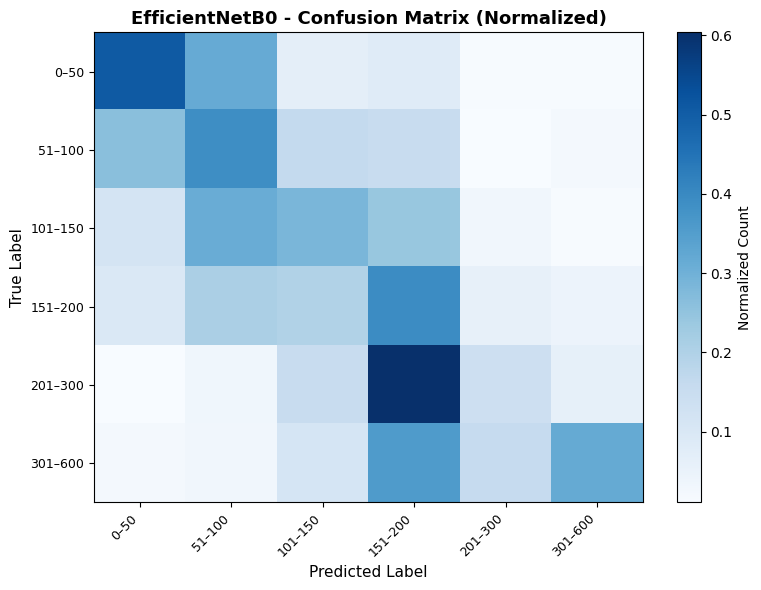

Confusion matrix saved as 'efficientnetb0_confusion_matrix.png'


In [103]:
# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

im = ax.imshow(cm_normalized, cmap='Blues', aspect='auto')
ax.set_title(f'{CONFIG["model_name"]} - Confusion Matrix (Normalized)', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(class_names, fontsize=9)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Normalized Count', fontsize=10)

plt.tight_layout()
plt.savefig('efficientnetb0_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("Confusion matrix saved as 'efficientnetb0_confusion_matrix.png'")

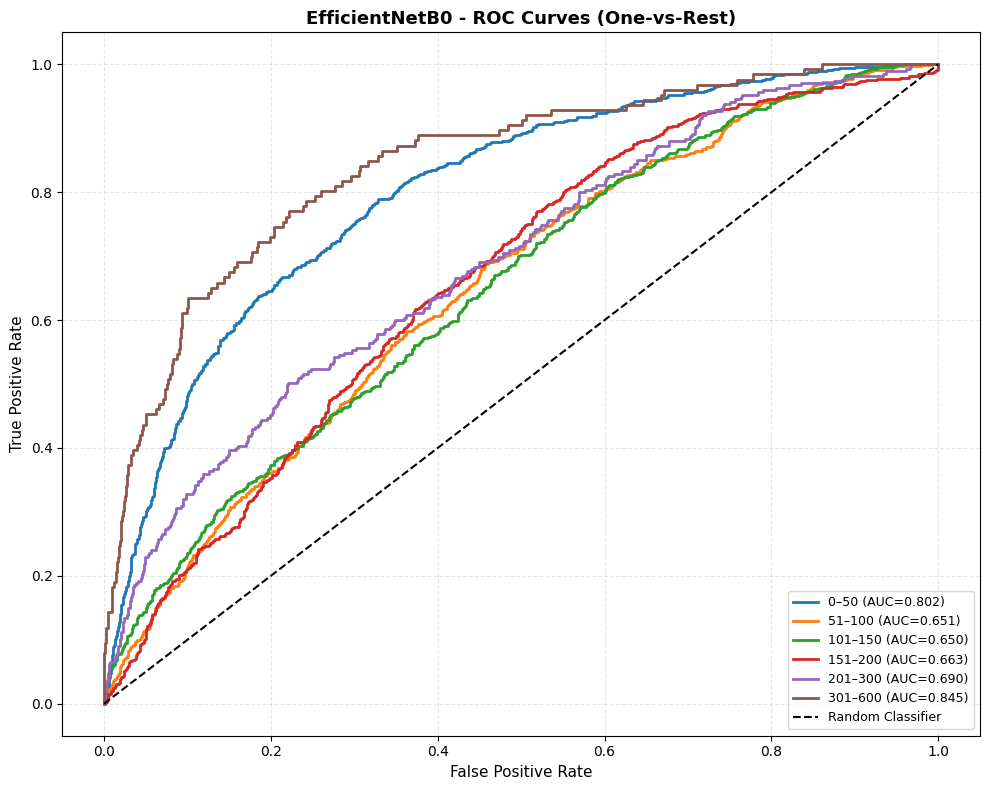

ROC curves saved as 'efficientnetb0_roc_curves.png'


In [104]:
# Plot ROC Curves
fig, ax = plt.subplots(figsize=(10, 8))

for class_idx in range(num_classes):
    y_true_binary = (y_true == class_idx).astype(int)
    y_probs_class = y_probs[:, class_idx]
    
    fpr, tpr, _ = roc_curve(y_true_binary, y_probs_class)
    roc_auc = auc(fpr, tpr)
    
    ax.plot(fpr, tpr, label=f'{class_names[class_idx]} (AUC={roc_auc:.3f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1.5)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title(f'{CONFIG["model_name"]} - ROC Curves (One-vs-Rest)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('efficientnetb0_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("ROC curves saved as 'efficientnetb0_roc_curves.png'")

In [105]:
# Save Results
results = {
    'model': CONFIG['model_name'],
    'accuracy': float(accuracy),
    'precision': float(precision),
    'recall': float(recall),
    'f1': float(f1),
    'auc': float(auc_score),
    'train_time': float(train_time),
    'test_time': float(test_time),
    'epochs': CONFIG['epochs'],
    'batch_size': CONFIG['batch_size'],
    'learning_rate': CONFIG['learning_rate'],
    'class_accuracy': {class_names[i]: float(class_accuracy[i]) for i in range(num_classes)},
    'confusion_matrix': cm.tolist()
}

# Save to JSON
with open('efficientnetb0_results.json', 'w') as f:
    json.dump(results, f, indent=4)
print("Results saved to 'efficientnetb0_results.json'")

# Save confusion matrix to CSV
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_df.to_csv('efficientnetb0_confusion_matrix.csv')
print("Confusion matrix saved to 'efficientnetb0_confusion_matrix.csv'")

Results saved to 'efficientnetb0_results.json'
Confusion matrix saved to 'efficientnetb0_confusion_matrix.csv'


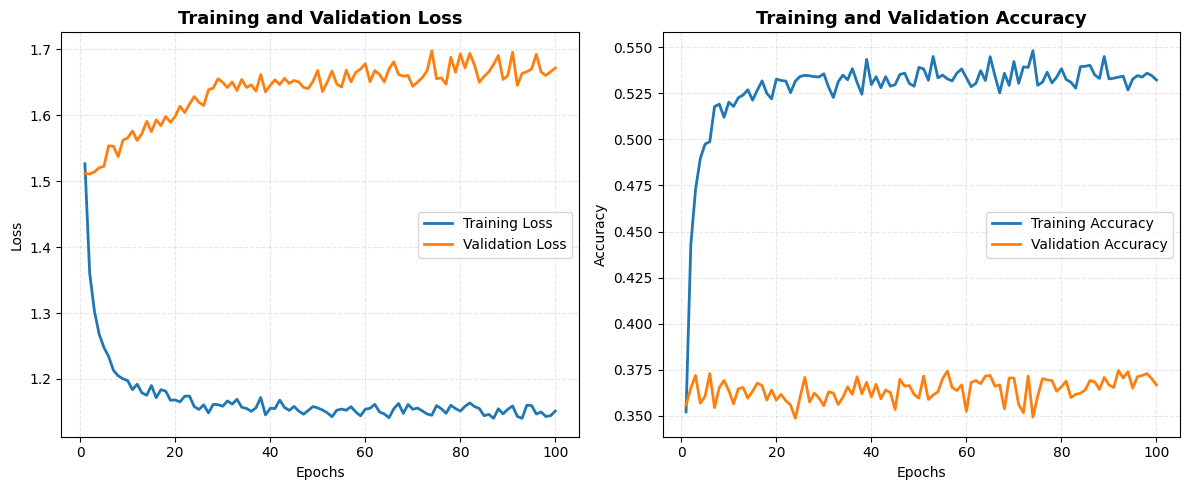

In [106]:
# Plot Learning Curves
def training_curves(train_loss_history, val_loss_history, train_acc_history, val_acc_history):
    epochs = range(1, len(train_loss_history) + 1)

    # Plot training and validation loss
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss_history, label='Training Loss', linewidth=2)
    plt.plot(epochs, val_loss_history, label='Validation Loss', linewidth=2)
    plt.title('Training and Validation Loss', fontsize=13, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(alpha=0.3, linestyle='--')

    # Plot training and validation accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc_history, label='Training Accuracy', linewidth=2)
    plt.plot(epochs, val_acc_history, label='Validation Accuracy', linewidth=2)
    plt.title('Training and Validation Accuracy', fontsize=13, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.savefig('efficientnetb0_training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

# Create learning curves with training and validation metrics
training_curves(train_losses, val_losses, train_accuracies, val_accuracies)